# 1D-CNN v8 — Enhanced Calibration Pipeline

Same base model as v6. Three calibration improvements:
1. SVM RBF as calibration classifier (non-linear, better than LogReg)
2. More calibration data for S1 (all positions, not just p0)
3. Ensemble: weighted vote of base model + calibrated classifier

In [15]:
import sys, math, copy
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.stats import mode

from config import RANDOM_SEED, N_CLASSES, MODELS_DIR, get_device, SUBJECTS_INTERDAY_LONG
from src.experiment_runner import (
    get_splits, load_and_norm, META,
    TEST_SUBJECTS, TRAIN_SUBJECTS,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = get_device()
splits = get_splits()
print(f'Device: {DEVICE}')

Device: mps


## Model (same as v6)

In [16]:
class ECA1d(nn.Module):
    def __init__(self,ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2+0.5)),3); k = k if k%2 else k+1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1,1,k,padding=k//2,bias=False)
    def forward(self,x):
        b,c,t = x.size()
        return x * torch.sigmoid(self.conv(self.gap(x).view(b,1,c))).view(b,c,1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self,ic,oc,k=5,p=2):
        super().__init__()
        self.dw = nn.Conv1d(ic,ic,k,padding=p,groups=ic)
        self.pw = nn.Conv1d(ic,oc,1)
    def forward(self,x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self,in_ch=8,n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64,128,5,2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128,256,3,1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256,64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64,n_classes),
        )
    def forward(self,x): return self.classifier(self.features(x))
    def extract_feat(self,x):
        with torch.no_grad(): return nn.Flatten()(self.features(x))

print(f'Params: {sum(p.numel() for p in TemporalSCNN().parameters()):,}')

Params: 62,676


## Training (same as v6)

In [17]:
train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

model = TemporalSCNN().to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / '1dcnn_v6.pt', map_location=DEVICE))
model.eval()
print('Loaded 1dcnn_v6.pt')

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2538.88it/s]


Train: (1030712, 8, 50)
Loaded 1dcnn_v6.pt


## Prediction + Feature extraction

In [18]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

@torch.no_grad()
def base_proba(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    probs = []
    for (xb,) in loader:
        logits = model(xb.to(DEVICE))
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def extract_features(X):
    model.eval()
    Xt = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=512, shuffle=False)
    return np.concatenate([model.extract_feat(xb[0].to(DEVICE)).cpu().numpy() for xb in loader])

## Enhanced calibration: SVM RBF + ensemble

In [19]:
def calibrate_svm(X_cal, y_cal):
    F_cal = extract_features(X_cal)
    # Augment: rotate channels in feature space
    # Extract features from rotated versions too
    X_rot = np.roll(X_cal, shift=1, axis=1)
    X_rot2 = np.roll(X_cal, shift=-1, axis=1)
    F_rot = extract_features(X_rot)
    F_rot2 = extract_features(X_rot2)
    F_all = np.vstack([F_cal, F_rot, F_rot2])
    y_all = np.concatenate([y_cal, y_cal, y_cal])
    
    sc = StandardScaler().fit(F_all)
    F_all_s = sc.transform(F_all)
    svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(F_all_s, y_all)
    return svm, sc

def ensemble_predict(X, svm, sc, base_weight=0.4, cal_weight=0.7):
    """Weighted ensemble: base model softmax + SVM calibrated probability."""
    # Base model probabilities
    p_base = base_proba(X)  # (N, 7)

    # SVM calibrated probabilities
    F = extract_features(X)
    F_s = sc.transform(F)
    p_cal = svm.predict_proba(F_s)  # (N, 7)

    # Weighted average
    p_combined = base_weight * p_base + cal_weight * p_cal
    return p_combined.argmax(axis=1)


def full_calibration(X_cal, y_cal, X_test):
    """Full pipeline: SVM calibration + ensemble."""
    svm, sc = calibrate_svm(X_cal, y_cal)
    return ensemble_predict(X_test, svm, sc)

## Option B — Zero-shot

In [20]:
print('Option B — Zero-shot:')
zero_results = {}
for sname, test_df in [('S1', splits['s1_test']), ('S2', splits['s2_test']),
                        ('S3', splits['s3_test']), ('S4', splits['s4_test']),
                        ('S5', splits['s5_test'])]:
    X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
    acc = accuracy_score(y_t, base_predict(X_t))
    zero_results[sname] = acc
    print(f'  {sname}: {acc:.4f}')

Option B — Zero-shot:
  S1: 0.5862
  S2: 0.5352
  S3: 0.5398
  S4: 0.6556
  S5: 0.8029


---
## Option A — Enhanced Calibration

### S1: per-subject, rep 0 from ALL positions (not just p0)

In [21]:
# S1: use rep 0 from ALL positions as calibration (much more data)
subset_s1_full = META[(META['session'] == 0) & (META['subject'].isin(TEST_SUBJECTS))]

s1_base, s1_cal = [], []
for subj in TEST_SUBJECTS:
    sdf = subset_s1_full[subset_s1_full['subject'] == subj]
    cal_df = sdf[sdf['repetition'].isin([0, 1])]
    test_df = sdf[sdf['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    s1_base.append(accuracy_score(y_test, base_predict(X_test)))
    y_pred = full_calibration(X_cal, y_cal, X_test)
    s1_cal.append(accuracy_score(y_test, y_pred))
    print(f'  {subj}: base={s1_base[-1]:.4f}  cal={s1_cal[-1]:.4f}')

cal_s1 = np.mean(s1_cal)
print(f'\nS1 avg: base={np.mean(s1_base):.4f}  cal={cal_s1:.4f}')

  h7: base=0.5737  cal=0.9201
  h22: base=0.6138  cal=0.8330
  h3: base=0.5017  cal=0.8293
  h24: base=0.5288  cal=0.8820
  h16: base=0.5420  cal=0.8908
  h17: base=0.4174  cal=0.8570

S1 avg: base=0.5296  cal=0.8687


### S2: per-position calibration

In [22]:
subset_s2 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS)) & (META['position']>0)]

s2_accs = []
for pos in sorted(subset_s2['position'].unique()):
    pos_df = subset_s2[subset_s2['position'] == pos]
    cal_df = pos_df[pos_df['repetition'].isin([0, 1])]
    test_df = pos_df[pos_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s2_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f}')

cal_s2 = np.mean(s2_accs)
print(f'\nS2 avg: {cal_s2:.4f}')

  Pos  1: 0.7969
  Pos  2: 0.8649
  Pos  3: 0.8005
  Pos  4: 0.8252
  Pos  5: 0.8595
  Pos  6: 0.7932
  Pos  7: 0.8438
  Pos  8: 0.8115
  Pos  9: 0.8260
  Pos 10: 0.7927

S2 avg: 0.8214


### S3: per-subject, rep 0 all positions

In [23]:
subset_s3 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

s3_accs = []
all_yt, all_yp = [], []
for subj in TEST_SUBJECTS:
    sdf = subset_s3[subset_s3['subject'] == subj]
    cal_df = sdf[sdf['repetition'].isin([0, 1])]
    test_df = sdf[sdf['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s3_accs.append(acc)
    all_yt.extend(y_test); all_yp.extend(y_pred)
    print(f'  {subj}: {acc:.4f} (cal={len(cal_df)} trials)')

cal_s3 = np.mean(s3_accs)
print(f'\nS3 avg: {cal_s3:.4f}')
print_report(np.array(all_yt), np.array(all_yp), title='v8 — S3')

  h7: 0.9201 (cal=154 trials)
  h22: 0.8330 (cal=154 trials)
  h3: 0.8293 (cal=154 trials)
  h24: 0.8820 (cal=153 trials)
  h16: 0.8908 (cal=154 trials)
  h17: 0.8570 (cal=154 trials)

S3 avg: 0.8687

  v8 — S3
  Accuracy:  0.8676
  F1-macro:  0.8676
                    precision    recall  f1-score   support

              fist       0.90      0.87      0.89      7959
         open_hand       0.84      0.87      0.85      8060
  pinch_forefinger       0.85      0.80      0.83      8091
pinch_middlefinger       0.86      0.86      0.86      8099
               two       0.88      0.88      0.88      7970
          eversion       0.88      0.92      0.90      7903
             varus       0.87      0.86      0.87      8064

          accuracy                           0.87     56146
         macro avg       0.87      0.87      0.87     56146
      weighted avg       0.87      0.87      0.87     56146



{'accuracy': 0.8676308196487729, 'f1_macro': 0.8675920168574608}

### S4: per-session calibration

In [24]:
interday_subjects = [s for s in SUBJECTS_INTERDAY_LONG if s in TRAIN_SUBJECTS]
subset_s4 = META[(META['subject'].isin(interday_subjects)) & (META['position']==0) & (META['session']>0)]

s4_accs = []
for sess in sorted(subset_s4['session'].unique()):
    sess_df = subset_s4[subset_s4['session'] == sess]
    cal_df = sess_df[sess_df['repetition'].isin([0, 1])]
    test_df = sess_df[sess_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s4_accs.append(acc)
    print(f'  Session {sess}: {acc:.4f}')

cal_s4 = np.mean(s4_accs)
print(f'\nS4 avg: {cal_s4:.4f}')

  Session 1: 0.8254
  Session 2: 0.8692
  Session 3: 0.8558
  Session 4: 0.8710
  Session 5: 0.8722
  Session 6: 0.8365
  Session 7: 0.8353
  Session 8: 0.9005
  Session 9: 0.8752

S4 avg: 0.8601


### S5: per-position calibration

In [25]:
from config import SUBJECTS_FATIGUE
subset_s5 = META[(META['subject'].isin(SUBJECTS_FATIGUE)) & (META['position']>=2)]

s5_accs = []
for pos in sorted(subset_s5['position'].unique()):
    pos_df = subset_s5[subset_s5['position'] == pos]
    cal_df = pos_df[pos_df['repetition'].isin([0, 1])]
    test_df = pos_df[pos_df['repetition'] == 2]
    if len(cal_df) == 0 or len(test_df) == 0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred = full_calibration(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s5_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f}')

cal_s5 = np.mean(s5_accs)
print(f'\nS5 avg: {cal_s5:.4f}')

  Pos  2: 0.8535
  Pos  3: 0.8369
  Pos  4: 0.8768
  Pos  5: 0.8874
  Pos  6: 0.8954
  Pos  7: 0.8734
  Pos  8: 0.8771
  Pos  9: 0.8805
  Pos 10: 0.8880

S5 avg: 0.8743


## Latency

In [26]:
model.eval()
s = torch.randn(1,8,50).to(DEVICE)
for _ in range(10): _ = model(s)
if DEVICE.type=='mps': torch.mps.synchronize()
def pred_single(x):
    xt = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = model(xt)
    if DEVICE.type=='mps': torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()
latency = measure_latency(pred_single, X_train[:1], n_runs=500)
print_latency(latency, '1D-CNN v8')


Latency — 1D-CNN v8
  Mean:   1.26 ms
  Median: 1.21 ms
  P95:    1.36 ms
  <300ms: ✓


## Final Results


  1D-CNN v8 — FINAL RESULTS
Scenario        Zero-shot    v6 LogReg   v8 SVM+Ens   ≥85%
-----------------------------------------------------------------
S1                58.62%       70.46%       86.87%     ✓ (Δ=+16.41%)
S2                53.52%       76.57%       82.14%       (Δ=+5.57%)
S3                53.98%       76.75%       86.87%     ✓ (Δ=+10.12%)
S4                65.56%       81.37%       86.01%     ✓ (Δ=+4.64%)
S5                80.29%       86.23%       87.43%     ✓ (Δ=+1.20%)
-----------------------------------------------------------------
Average           62.39%       78.28%       85.87%


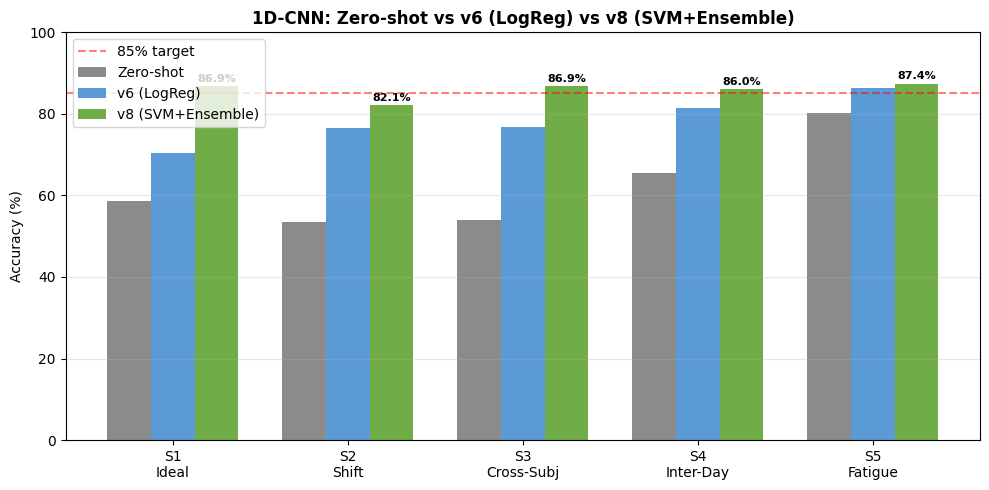

In [27]:
import matplotlib.pyplot as plt

cal_results = {'S1': cal_s1, 'S2': cal_s2, 'S3': cal_s3, 'S4': cal_s4, 'S5': cal_s5}

print('\n' + '=' * 65)
print('  1D-CNN v8 — FINAL RESULTS')
print('=' * 65)
print(f'{"Scenario":<12} {"Zero-shot":>12} {"v6 LogReg":>12} {"v8 SVM+Ens":>12} {"≥85%":>6}')
print('-' * 65)

v6_cal = {'S1': 70.46, 'S2': 76.57, 'S3': 76.75, 'S4': 81.37, 'S5': 86.23}

for s in ['S1','S2','S3','S4','S5']:
    zs = zero_results[s] * 100
    v6 = v6_cal[s]
    v8 = cal_results[s] * 100
    delta = v8 - v6
    check = '✓' if v8 >= 85 else ''
    print(f'{s:<12} {zs:>10.2f}%  {v6:>10.2f}%  {v8:>10.2f}%  {check:>4} (Δ={delta:+.2f}%)')

print('-' * 65)
avg_zs = np.mean([zero_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
avg_v6 = np.mean(list(v6_cal.values()))
avg_v8 = np.mean([cal_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
print(f'{"Average":<12} {avg_zs:>10.2f}%  {avg_v6:>10.2f}%  {avg_v8:>10.2f}%')
print('=' * 65)

# Bar chart comparison
scenarios = ['S1','S2','S3','S4','S5']
x = np.arange(5)
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, [zero_results[s]*100 for s in scenarios], w, label='Zero-shot', color='#8B8B8B')
ax.bar(x, [v6_cal[s] for s in scenarios], w, label='v6 (LogReg)', color='#5B9BD5')
ax.bar(x + w, [cal_results[s]*100 for s in scenarios], w, label='v8 (SVM+Ensemble)', color='#70AD47')
ax.axhline(y=85, color='red', ls='--', alpha=0.5, label='85% target')
ax.set_xticks(x)
ax.set_xticklabels(['S1\nIdeal', 'S2\nShift', 'S3\nCross-Subj', 'S4\nInter-Day', 'S5\nFatigue'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('1D-CNN: Zero-shot vs v6 (LogReg) vs v8 (SVM+Ensemble)', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, s in enumerate(scenarios):
    ax.text(i+w, cal_results[s]*100+1, f'{cal_results[s]*100:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(str(Path(PROJECT_ROOT) / 'results' / 'figures' / '1dcnn_v8_comparison.png'), dpi=150)
plt.show()